<a href="https://colab.research.google.com/github/chiderakanu5-creator/SPAM-CLASSIFIER-3/blob/main/SPAM_CLASSIFIER_1A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CAPSTONE PROJECT GROUP 3 - SPAM EMAIL CLASSIFIER

## 1. IMPORTING THE NECESSARY LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
import pickle
import re
import string
import joblib
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


### 1.1 IMPORTING THE DATASET FROM MY DOWNLOADED FILES

In [2]:
df = pd.read_csv('/content/spam.csv', encoding='latin1')

## 2. VIEWING THE PROPERTIES OF THE DATASET

### 2.1 Vieing Shape of Dataframe
This shows that they are 5 columns and 5,572 rows in the data set.


In [3]:
df.shape

(5572, 5)

### 2.2. Dataset information;
This gives a summary of the information contained in the dataset as it concerns the number of entries, rows/columns, datatype, missing values etc

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [5]:
print(f"\nColumn names: {df.columns.tolist()}")


Column names: ['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']


### 2.3 Dataset Preview - from head or tail:
This displays a range of the set, either from the top or bottom entries.

In [6]:
df.head(20)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
5,spam,FreeMsg Hey there darling it's been 3 week's n...,NaN,NaN,NaN
6,ham,Even my brother is not like to speak with me. ...,NaN,NaN,NaN
7,ham,As per your request 'Melle Melle (Oru Minnamin...,NaN,NaN,NaN
8,spam,WINNER!! As a valued network customer you have...,NaN,NaN,NaN
9,spam,Had your mobile 11 months or more? U R entitle...,NaN,NaN,NaN


In [7]:
df.tail()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN
5571,ham,Rofl. Its true to its name,NaN,NaN,NaN


### 2.4 Describing the dataframe:
This gives the statistical analysis of the dataset where necessary.

In [8]:
df.describe()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


In [9]:
df.describe().T

,count,unique,top,freq
v1,5572,2,ham,4825
v2,5572,5169,"Sorry, I'll call later",30
Unnamed: 2,50,43,"bt not his girlfrnd... G o o d n i g h t . . .@""",3
Unnamed: 3,12,10,"MK17 92H. 450Ppw 16""",2
Unnamed: 4,6,5,"GNT:-)""",2


## 3. DATA PREPROCESSING AND CLEANING

### 3.1 Dropping irrelevant columns

In [10]:
df = df.drop(columns=['Unnamed: 2',	'Unnamed: 3',	'Unnamed: 4',])

### 3.2 Renaming v1 and v2 to Label and text respectively

In [11]:
df=df.rename(columns={"v1":"Label","v2":"text"})

### 3.3 Checking for missing values

In [12]:
df.isnull().sum()

,0
Label,0
text,0


### 3.4 Checking for duplicates and removing duplicates

In [13]:
duplicates_before = len(df)
df = df.drop_duplicates()
duplicates_after = len(df)
print(f"\nDuplicates removed: {duplicates_before - duplicates_after}")


Duplicates removed: 403


In [14]:
# Check class distribution
print(f"\nClass distribution (before cleaning):")
print(df['Label'].value_counts())
print(f"Class percentage:")
print(df['Label'].value_counts(normalize=True) * 100)

# Remove missing values
df = df.dropna()
print(f"Dataset shape after cleaning: {df.shape}")

# Convert labels to numeric (ham=0, spam=1)
df['Label'] = (df['Label'] == 'spam').astype(int)


Class distribution (before cleaning):
Label
ham     4516
spam     653
Name: count, dtype: int64
Class percentage:
Label
ham     87.366996
spam    12.633004
Name: proportion, dtype: float64
Dataset shape after cleaning: (5169, 2)


### Text preprocessing - remove URLs, emails, and special characters

In [15]:
def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    # Remove special characters but keep spaces
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("\nCleaning text...")
df['text'] = df['text'].apply(clean_text)

# Remove empty texts
df = df[df['text'].str.len() > 0]
print(f"Dataset shape after text cleaning: {df.shape}")


Cleaning text...
Dataset shape after text cleaning: (5167, 2)


## 4. Feature Extraction

In [16]:
# Create vectorizer with optimized parameters
vectorizer = TfidfVectorizer(
    max_features=3000,           # Limit features for efficiency
    min_df=2,                    # Minimum document frequency
    max_df=0.9,                  # Maximum document frequency
    ngram_range=(1, 2),          # Unigrams and bigrams
    stop_words='english',
    lowercase=True
)

X = vectorizer.fit_transform(df['text'])
y = df['Label']

print(f"Feature matrix shape: {X.shape}")
print(f"Number of features: {X.shape[1]}")
print(f"Sparsity: {1.0 - (X.nnz / (X.shape[0] * X.shape[1])):.2%}")

Feature matrix shape: (5167, 3000)
Number of features: 3000
Sparsity: 99.77%


## 5. Test - Train Split

Here we are using 20% of the total dataset after cleaning for the testing while the remaining 80% will be used for training










In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} ({X_train.shape[0]/len(y)*100:.1f}%)")
print(f"Test set size: {X_test.shape[0]} ({X_test.shape[0]/len(y)*100:.1f}%)")
print(f"Training spam ratio: {y_train.sum()/len(y_train)*100:.1f}%")
print(f"Test spam ratio: {y_test.sum()/len(y_test)*100:.1f}%")

Training set size: 4133 (80.0%)
Test set size: 1034 (20.0%)
Training spam ratio: 12.6%
Test spam ratio: 12.7%


In [18]:
clf = RandomForestClassifier(n_jobs=-1)
clf.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1)

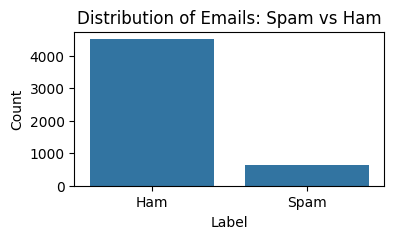

In [19]:
plt.figure(figsize=(4, 2))
sns.countplot(x='Label', data=df)
plt.title('Distribution of Emails: Spam vs Ham')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Ham', 'Spam'])
plt.show()

### 6. Train Multiple Models

In [20]:
# Dictionary to store models and their results
models = {}
results = {}

# Model 1: Naive Bayes
print("\n  Training Naive Bayes...")
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)
nb_pred_proba = nb_model.predict_proba(X_test)

models['Naive Bayes'] = nb_model
results['Naive Bayes'] = {
    'predictions': nb_pred,
    'probabilities': nb_pred_proba
}

# Model 2: Logistic Regression
print("  Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42, C=0.5)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_pred_proba = lr_model.predict_proba(X_test)

models['Logistic Regression'] = lr_model
results['Logistic Regression'] = {
    'predictions': lr_pred,
    'probabilities': lr_pred_proba
}

# Model 3: Support Vector Machine
print("  Training Support Vector Machine...")
svm_model = SVC(kernel='linear', probability=True, random_state=42, C=1.0)
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)
svm_pred_proba = svm_model.predict_proba(X_test)

models['SVM'] = svm_model
results['SVM'] = {
    'predictions': svm_pred,
    'probabilities': svm_pred_proba
}



  Training Naive Bayes...
  Training Logistic Regression...
  Training Support Vector Machine...


### 7. Evaluating Models

In [21]:
print("\n" + "="*70)

eval_results = {}

for model_name, model_obj in models.items():
    y_pred = results[model_name]['predictions']

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    eval_results[model_name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

    print(f"\n{model_name}:")
    print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  Precision: {precision:.4f} ({precision*100:.2f}%)")
    print(f"  Recall:    {recall:.4f} ({recall*100:.2f}%)")
    print(f"  F1 Score:  {f1:.4f}")



Naive Bayes:
  Accuracy:  0.9836 (98.36%)
  Precision: 0.9831 (98.31%)
  Recall:    0.8855 (88.55%)
  F1 Score:  0.9317

Logistic Regression:
  Accuracy:  0.9217 (92.17%)
  Precision: 0.9808 (98.08%)
  Recall:    0.3893 (38.93%)
  F1 Score:  0.5574

SVM:
  Accuracy:  0.9797 (97.97%)
  Precision: 0.9741 (97.41%)
  Recall:    0.8626 (86.26%)
  F1 Score:  0.9150


# 8. Choosing the most optimal model

---



In [22]:
best_model_name = max(eval_results, key=lambda x: eval_results[x]['f1'])
best_model = models[best_model_name]
best_f1 = eval_results[best_model_name]['f1']

print(f"\n✓ Best Model: {best_model_name} (F1 Score: {best_f1:.4f})")


✓ Best Model: Naive Bayes (F1 Score: 0.9317)


### 9. Confusion Matrix & Detailed Report

In [23]:
y_pred_best = results[best_model_name]['predictions']
cm = confusion_matrix(y_test, y_pred_best)

print(f"\nConfusion Matrix:")
print(cm)
print(f"\nTrue Negatives: {cm[0][0]}")
print(f"False Positives: {cm[0][1]}")
print(f"False Negatives: {cm[1][0]}")
print(f"True Positives: {cm[1][1]}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Ham', 'Spam']))


Confusion Matrix:
[[901   2]
 [ 15 116]]

True Negatives: 901
False Positives: 2
False Negatives: 15
True Positives: 116

Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       903
        Spam       0.98      0.89      0.93       131

    accuracy                           0.98      1034
   macro avg       0.98      0.94      0.96      1034
weighted avg       0.98      0.98      0.98      1034



### 10. Testing on Examples

In [24]:
test_examples = [
    ("FDFVOJ[S[OJFO[AESTABFOD]K       FD0FJ=ZD-]KALDS[C", "Gibberish"),
    ("Click here to win $1000 prize now!", "Spam"),
    ("Congratulations you won a lottery", "Spam"),
    ("Hi, how are you doing today?", "Ham"),
    ("Call me ASAP!", "Ham"),
    ("FREE money click here", "Spam"),
    ("Meeting at 3pm tomorrow", "Ham"),
    ("You have inherited 1 million dollars", "Spam"),
]

print("\nSample Predictions:")
for text, expected in test_examples:
    # Clean the text using same preprocessing
    cleaned_text = clean_text(text)
    transformed = vectorizer.transform([cleaned_text])

    pred = best_model.predict(transformed)[0]
    proba = best_model.predict_proba(transformed)[0]

    predicted_label = "SPAM" if pred == 1 else "HAM"
    confidence = proba[pred] * 100

    status = "✓" if (pred == 1 and expected == "Spam") or (pred == 0 and expected == "Ham") else "✗"

    print(f"\n{status} Text: '{text}'")
    print(f"   Expected: {expected} | Predicted: {predicted_label} ({confidence:.1f}% confidence)")


Sample Predictions:

✗ Text: 'FDFVOJ[S[OJFO[AESTABFOD]K       FD0FJ=ZD-]KALDS[C'
   Expected: Gibberish | Predicted: HAM (87.4% confidence)

✓ Text: 'Click here to win $1000 prize now!'
   Expected: Spam | Predicted: SPAM (100.0% confidence)

✓ Text: 'Congratulations you won a lottery'
   Expected: Spam | Predicted: SPAM (99.5% confidence)

✓ Text: 'Hi, how are you doing today?'
   Expected: Ham | Predicted: HAM (99.7% confidence)

✓ Text: 'Call me ASAP!'
   Expected: Ham | Predicted: HAM (60.3% confidence)

✓ Text: 'FREE money click here'
   Expected: Spam | Predicted: SPAM (79.9% confidence)

✓ Text: 'Meeting at 3pm tomorrow'
   Expected: Ham | Predicted: HAM (99.5% confidence)

✗ Text: 'You have inherited 1 million dollars'
   Expected: Spam | Predicted: HAM (94.8% confidence)


### 11. Save Data

In [25]:
spam_classifier = {
    'model_type': best_model_name,
    'accuracy': eval_results[best_model_name]['accuracy'],
    'precision': eval_results[best_model_name]['precision'],
    'recall': eval_results[best_model_name]['recall'],
    'f1_score': eval_results[best_model_name]['f1'],
    'features': X.shape[1],
    'classes': ['Ham', 'Spam']
}

# Save the metadata dictionary
spam_classifier_metadata_filename = 'spam_classifier_metadata.pkl'
joblib.dump(spam_classifier, spam_classifier_metadata_filename)

# Save the best model
model_filename = 'best_spam_model.pkl'
joblib.dump(best_model, model_filename)

# Save the vectorizer
vectorizer_filename = 'tfidf_vectorizer.pkl'
joblib.dump(vectorizer, vectorizer_filename)

print(f"\n✓ Spam classifier metadata saved: {spam_classifier_metadata_filename}")
print(f"✓ Best model saved: {model_filename}")
print(f"✓ TF-IDF vectorizer saved: {vectorizer_filename}")

print("\n" + "="*70)
print("TRAINING COMPLETE!")
print("="*70)
print("\n📋 Summary:")
print(f"  • Best Model: {best_model_name}")
print(f"  • Test Accuracy: {eval_results[best_model_name]['accuracy']*100:.2f}%")
print(f"  • F1 Score: {eval_results[best_model_name]['f1']:.4f}")
print(f"\n📁 Files to download:")
print(f"  1. {model_filename}")
print(f"  2. {vectorizer_filename}")
print(f"  3. {spam_classifier_metadata_filename}")


✓ Spam classifier metadata saved: spam_classifier_metadata.pkl
✓ Best model saved: best_spam_model.pkl
✓ TF-IDF vectorizer saved: tfidf_vectorizer.pkl

TRAINING COMPLETE!

📋 Summary:
  • Best Model: Naive Bayes
  • Test Accuracy: 98.36%
  • F1 Score: 0.9317

📁 Files to download:
  1. best_spam_model.pkl
  2. tfidf_vectorizer.pkl
  3. spam_classifier_metadata.pkl


In [26]:
!pip install streamlit
import streamlit as st

model = joblib.load("best_spam_model.pkl")
vectorizer = joblib.load("tfidf_vectorizer.pkl")

st.title("🔒 Spam Classifier")

email_text = st.text_area("Enter Email Text", placeholder="Paste your email here...")

if st.button("Classify Email"):
    if email_text.strip() == "":
        st.warning("⚠️ Please enter email text to classify.")
    else:
        transformed = vectorizer.transform([email_text])
        prediction = model.predict(transformed)
        confidence = model.predict_proba(transformed).max()

        if prediction[0] == 1:
            st.error(f"🚨 **Spam Detected** (Confidence: {confidence:.2%})")
        else:
            st.success(f"✅ **Legitimate Email** (Confidence: {confidence:.2%})")

        # Show top spam indicators
        st.markdown("---")
        st.info(f"Classification Confidence: {confidence:.2%}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 64.3 MB/s eta 0:00:00


2026-06-04 20:25:21.380 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 20:25:21.620 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-06-04 20:25:21.621 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 20:25:21.625 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 20:25:21.627 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 20:25:21.629 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 20:25:21.630 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 20:25:21.632 Thread 'MainThread': mi

In [27]:
%%writefile app.py
import streamlit as st
import joblib

# Load the trained model and vectorizer
model = joblib.load("best_spam_model.pkl")
vectorizer = joblib.load("tfidf_vectorizer.pkl")

# Streamlit app title
st.title("🔒 Spam Classifier")

# Text area for user input
email_text = st.text_area("Enter Email Text", placeholder="Paste your email here...")

# Classify button
if st.button("Classify Email"):
    if email_text.strip() == "":
        st.warning("⚠️ Please enter email text to classify.")
    else:
        # Clean and transform the input text
        # Assuming clean_text function is available or defined within app.py if needed.
        # For this example, let's assume it's part of the pre-processing chain handled by the vectorizer or model.
        # If clean_text was a separate function, it would need to be included here.

        # For now, directly transform. In a real deployment, ensure clean_text is applied.
        transformed = vectorizer.transform([email_text])

        # Make prediction
        prediction = model.predict(transformed)
        confidence = model.predict_proba(transformed).max()

        # Display results
        if prediction[0] == 1:
            st.error(f"🚨 **Spam Detected** (Confidence: {confidence:.2%})")
        else:
            st.success(f"✅ **Legitimate Email** (Confidence: {confidence:.2%})")

        st.markdown("---")
        st.info(f"Classification Confidence: {confidence:.2%}")


Writing app.py


In [28]:
from google.colab import files

files_to_download = [
    'best_spam_model.pkl',
    'tfidf_vectorizer.pkl',
    'spam_classifier_metadata.pkl',
    'app.py'
]

for file_name in files_to_download:
    try:
        files.download(file_name)
    except FileNotFoundError:
        print(f"Warning: {file_name} not found. Please ensure it was created correctly.")
    except Exception as e:
        print(f"Error downloading {file_name}: {e}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

###